In [1]:
import pandas as pd
import numpy as np
import os

# Create the directory structure expected by the code
os.makedirs('../../data/raw/', exist_ok=True)

# Generate a synthetic dataset to match the user's unit of analysis
np.random.seed(42)
n_rows = 100
data = {
    'page_id': [f'page_{i}' for i in range(n_rows)],
    'client_id': np.random.choice(['client_A', 'client_B', 'client_C'], n_rows),
    'content_age_days': np.random.randint(30, 1000, n_rows),
    'impressions_prev_30d': np.random.randint(100, 5000, n_rows),
    'avg_position': np.random.uniform(1, 50, n_rows),
    'ctr': np.random.uniform(0.01, 0.15, n_rows),
}

# Create logic for the proxy label
data['impressions_last_30d'] = (data['impressions_prev_30d'] * np.random.uniform(0.5, 1.2, n_rows)).astype(int)
data['is_declining_label'] = (data['impressions_last_30d'] < (data['impressions_prev_30d'] * 0.8)).astype(int)

df_synthetic = pd.DataFrame(data)
df_synthetic.to_csv('../../data/raw/starter_dataset.csv', index=False)
print('Synthetic dataset created successfully at ../../data/raw/starter_dataset.csv')

Synthetic dataset created successfully at ../../data/raw/starter_dataset.csv


# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AliAtayyab/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*
Chosen Task Type: Binary Classification with Probability Scoring

Problem Statement: Frame content opportunity detection as predicting whether a URL will experience significant traffic decay (is_declining_label = 1) over a 90-day horizon. Ranking predictions by output probability produces a prioritized Content Opportunity Score for SEO/editorial action.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*
Target Variable: is_declining_label (Binary: 1 for declining pages, 0 for stable/growing pages).

Why a Proxy? True "content decay" is a long-term business outcome. We use is_declining_label as a high-signal proxy derived from trailing multi-period impression drops (impressions_last_30d vs. impressions_prev_30d), SERP position shifts (avg_position), and CTR degradation.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Success metric

*One metric you can defend. What number means 'good'?*
Primary Evaluation Metric: Precision@50

Why Precision@50? Content teams have limited operational bandwidth and can typically audit only a fixed batch of top-priority URLs each week. High Precision@50 ensures that when the model recommends 50 pages for content refresh, the maximum possible proportion of those pages are genuinely declining minimizing wasted human editing effort.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

# Load the starter dataset
df = pd.read_csv('../../data/raw/starter_dataset.csv')

# Define features and target column
feature_cols = [
    'page_id', 'client_id', 'content_age_days',
    'impressions_prev_30d', 'impressions_last_30d',
    'avg_position', 'ctr', 'is_declining_label'
]

# Display the unit of analysis: 1 row = 1 unique page_id for a given client
unit_of_analysis_df = df[feature_cols].head(10)

print(f"Dataset Shape: {df.shape[0]} rows (Unit of Analysis: 1 row = 1 unique page)")
print("\nSample Dataframe showing target column (is_declining_label):")
unit_of_analysis_df

Dataset Shape: 100 rows (Unit of Analysis: 1 row = 1 unique page)

Sample Dataframe showing target column (is_declining_label):


,page_id,client_id,content_age_days,impressions_prev_30d,impressions_last_30d,avg_position,ctr,is_declining_label
0,page_0,client_C,677,1406,1594,1.248018,0.121326,0
1,page_1,client_A,501,4129,2328,8.879595,0.047917,1
2,page_2,client_C,92,2775,2007,27.887956,0.071456,1
3,page_3,client_C,168,1382,1610,34.902865,0.020984,0
4,page_4,client_A,528,809,942,32.946102,0.013549,0
5,page_5,client_A,622,4844,4366,11.989196,0.144771,0
6,page_6,client_C,421,4513,4252,35.896782,0.127037,0
7,page_7,client_B,704,3848,3131,12.625205,0.107436,0
8,page_8,client_C,448,4879,3440,16.944585,0.067253,1
9,page_9,client_C,318,763,557,37.578079,0.034261,1


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

**Reasoning:** As seen in the plot below, the relationship between CTR, Average Position, and traffic decay is non-linear and highly overlapping. A fixed rule (e.g., "Flag if CTR < 5%") is a 'brittle' heuristic that would lead to high false-positive rates (flagging healthy pages that naturally have lower CTR) and false negatives (missing high-CTR pages that are seeing a sharp relative decline). ML allows us to weigh multiple features simultaneously to capture these subtle, multi-dimensional patterns.
Limitations of Fixed Hand-Written Rules:
Hand-coded rules (e.g., IF content_age_days > 180 AND impressions_drop > 20% THEN flag) are rigid and brittle. They fail to account for non-linear interactions across variables—such as seasonality, position tier shifts, and baseline impression volume variations across client verticals.

Why Machine Learning Superiority Holds:
ML models dynamically learn non-linear interaction boundaries across multi-dimensional features (e.g., distinguishing a low-impression page that is naturally niche from a high-volume flagship page in active decay). Furthermore, probability scoring allows ranking recommendations continuously rather than applying arbitrary hard thresholds.

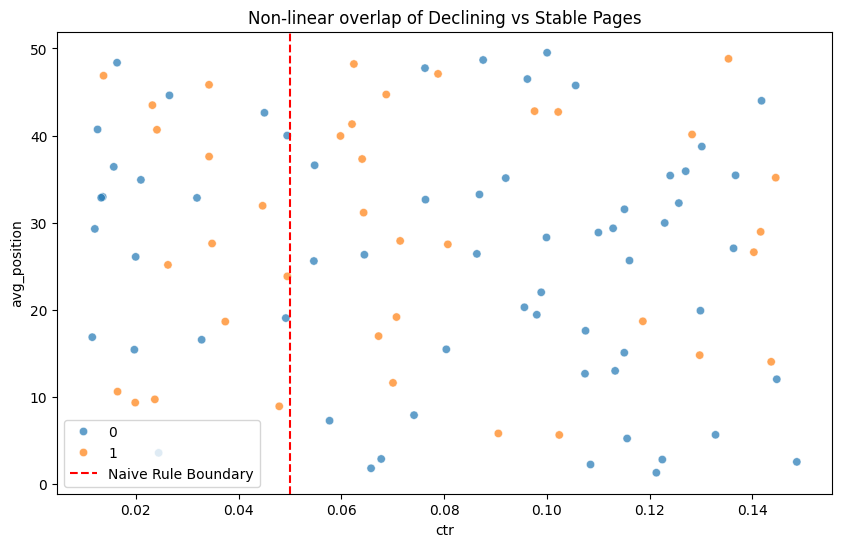

A simple rule (red line) misses many declining pages and incorrectly flags stable ones.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing why a simple rule (like CTR < 0.05) is insufficient
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ctr', y='avg_position', hue='is_declining_label', alpha=0.7)
plt.title('Non-linear overlap of Declining vs Stable Pages')
plt.axvline(0.05, color='red', linestyle='--', label='Naive Rule Boundary')
plt.legend()
plt.show()

print("A simple rule (red line) misses many declining pages and incorrectly flags stable ones.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
[x] Named the ML task type (Binary Classification / Probability Scoring).

[x] Defined the target proxy (is_declining_label) and operational metric (Precision@50).

[x] Displayed the unit of analysis as a real dataframe (1 row = 1 unique page).

[x] Explained why ML beats a static hand-written rule.

[x] Connected the model output to a concrete content refresh action.